# Fase 6 — Análisis de Fairness

**Variables de subgrupo:** `gender`, `race` (disponibles en la cohorte de MIMIC-IV-ED)  
**Métricas:** AUROC por subgrupo, Equal Opportunity Difference (EOD), Equalized Odds Difference (EqOdd)  
**Marco regulatorio:** AI Act (Reglamento UE 2024/1689, Anexo III) — sistemas de alto riesgo en salud.

> **EOD:** diferencia en TPR (sensibilidad) al umbral de Youden entre el grupo privilegiado y el desfavorecido. Un EOD > 0.05 se considera clínicamente relevante.  
> **EqOdd:** max(|ΔTPR|, |ΔFPR|) — penaliza tanto el sesgo en sensibilidad como en especificidad.

El análisis evalúa si los modelos mantienen un rendimiento equitativo entre subgrupos demográficos, requisito explícito de TRIPOD-AI para sistemas de apoyo a la decisión clínica.

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import roc_auc_score, roc_curve

np.random.seed(42)
sns.set_theme(style="whitegrid")
plt.rcParams.update({'figure.dpi': 150, 'font.size': 9})

ROOT    = Path("../..").resolve()
PREDS   = pd.read_parquet(ROOT / "data/processed/predictions_test.parquet")
TARGETS = ["L1", "L2", "L3"]
MODELS  = ["logreg", "catboost", "lstm", "tabtransformer", "nam"]
LABELS  = {"logreg": "LogReg+LASSO", "catboost": "CatBoost",
           "lstm": "LSTM", "tabtransformer": "TabTransformer", "nam": "NAM"}

print(f"Columnas disponibles: {list(PREDS.columns)}")
# Verificar variables demográficas
DEMO_COLS = [c for c in ["gender", "race"] if c in PREDS.columns]
print(f"Variables demográficas: {DEMO_COLS}")

Columnas disponibles: ['stay_id', 'L1_true', 'L2_true', 'L3_true', 'logreg_L1', 'logreg_L2', 'logreg_L3', 'catboost_L1', 'catboost_L2', 'catboost_L3', 'lstm_L1', 'lstm_L2', 'lstm_L3', 'tabtransformer_L1', 'tabtransformer_L2', 'tabtransformer_L3', 'nam_L1', 'nam_L2', 'nam_L3', 'gender', 'race']
Variables demográficas: ['gender', 'race']


## 2. AUROC por subgrupo demográfico

AUROC estratificado por `gender` y `race` para CatBoost (mejor modelo en validación). Se excluyen grupos con menos de 100 muestras o sin representación de ambas clases, para garantizar estimaciones estables.

In [2]:
MIN_GROUP_SIZE = 100  # Se omiten grupos con menos muestras para garantizar estimaciones estables

def auroc_by_group(df, group_col, target, model):
    rows = []
    for grp, sub in df.groupby(group_col):
        if len(sub) < MIN_GROUP_SIZE or sub[f"{target}_true"].nunique() < 2:
            continue
        auroc = roc_auc_score(sub[f"{target}_true"], sub[f"{model}_{target}"])
        rows.append({"Grupo": grp, "N": len(sub), "AUROC": auroc,
                     "Prev": sub[f"{target}_true"].mean()})
    return pd.DataFrame(rows).sort_values("AUROC", ascending=False)

# CatBoost se usa como modelo principal por su mejor discriminación en validación
MAIN_MODEL = "catboost"

for demo in DEMO_COLS:
    for t in TARGETS:
        df_grp = auroc_by_group(PREDS, demo, t, MAIN_MODEL)
        print(f"\n{demo} × {t} ({LABELS[MAIN_MODEL]}):")
        if df_grp.empty:
            print("  Sin grupos con N>=100 y ambas clases")
        else:
            print(df_grp.round(4).to_string(index=False))


gender × L1 (CatBoost):
Grupo     N  AUROC   Prev
    M 25884 0.8161 0.4291
    F 33757 0.8085 0.3782

gender × L2 (CatBoost):
Grupo     N  AUROC   Prev
    F 33757 0.8665 0.0134
    M 25884 0.8555 0.0173

gender × L3 (CatBoost):
Grupo     N  AUROC   Prev
    F 33757 0.8875 0.0053
    M 25884 0.8637 0.0064

race × L1 (CatBoost):
                             Grupo     N  AUROC   Prev
        HISPANIC/LATINO - HONDURAN   135 0.8901 0.2444
          ASIAN - SOUTH EAST ASIAN   156 0.8488 0.4103
                             ASIAN   828 0.8484 0.3188
                   ASIAN - CHINESE   987 0.8473 0.4245
                           UNKNOWN   216 0.8466 0.5833
                             OTHER  2357 0.8420 0.3186
                BLACK/CAPE VERDEAN  1482 0.8344 0.2544
                     BLACK/AFRICAN   552 0.8314 0.3188
         HISPANIC/LATINO - MEXICAN   107 0.8208 0.2243
      HISPANIC/LATINO - SALVADORAN   207 0.8165 0.2995
          WHITE - EASTERN EUROPEAN   222 0.8163 0.4685
       H

## 3. Equal Opportunity Difference (EOD) y Equalized Odds

EOD y EqOdd calculados al umbral de Youden global. La función `fairness_metrics` identifica automáticamente el grupo de referencia como el de mayor TPR si no se especifica uno explícitamente.

In [3]:
def youden_threshold(y_true, y_score):
    fpr, tpr, thr = roc_curve(y_true, y_score)
    j = tpr - fpr
    return thr[np.argmax(j)]

def tpr_fpr_at_threshold(y_true, y_score, t):
    pred = (y_score >= t).astype(int)
    tp = ((pred == 1) & (y_true == 1)).sum()
    fn = ((pred == 0) & (y_true == 1)).sum()
    fp = ((pred == 1) & (y_true == 0)).sum()
    tn = ((pred == 0) & (y_true == 0)).sum()
    tpr = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    return tpr, fpr

def fairness_metrics(df, group_col, target, model, ref_group=None):
    """EOD y EqOdd respecto al grupo de referencia (mayor AUROC si ref_group=None)."""
    # Se calcula el umbral de Youden sobre la población global
    thr = youden_threshold(df[f"{target}_true"].values, df[f"{model}_{target}"].values)

    groups = {g: sub for g, sub in df.groupby(group_col)
              if len(sub) >= MIN_GROUP_SIZE and sub[f"{target}_true"].nunique() == 2}
    if len(groups) < 2:
        return None

    results = {}
    for g, sub in groups.items():
        tpr, fpr = tpr_fpr_at_threshold(
            sub[f"{target}_true"].values, sub[f"{model}_{target}"].values, thr)
        results[g] = {"TPR": tpr, "FPR": fpr}

    if ref_group is None:
        ref_group = max(results, key=lambda g: results[g]["TPR"] or 0)

    rows = []
    for g, v in results.items():
        eod   = abs(v["TPR"] - results[ref_group]["TPR"]) if g != ref_group else 0
        eqodd = max(abs(v["TPR"] - results[ref_group]["TPR"]),
                    abs(v["FPR"] - results[ref_group]["FPR"])) if g != ref_group else 0
        rows.append({"Grupo": g, "TPR": v["TPR"], "FPR": v["FPR"],
                     "EOD": eod, "EqOdd": eqodd, "Ref": g == ref_group})
    return pd.DataFrame(rows).sort_values("EOD", ascending=False)

for demo in DEMO_COLS:
    for t in TARGETS:
        df_fair = fairness_metrics(PREDS, demo, t, MAIN_MODEL)
        print(f"\n{demo} × {t}:")
        if df_fair is None:
            print("  Datos insuficientes")
        else:
            print(df_fair.round(4).to_string(index=False))


gender × L1:
Grupo    TPR    FPR    EOD  EqOdd   Ref
    F 0.7164 0.2639 0.0166 0.0166 False
    M 0.7330 0.2683 0.0000 0.0000  True

gender × L2:
Grupo    TPR    FPR    EOD  EqOdd   Ref
    F 0.7894 0.2138 0.0231 0.0513 False
    M 0.8125 0.2651 0.0000 0.0000  True

gender × L3:
Grupo    TPR    FPR    EOD  EqOdd   Ref
    F 0.7278 0.1324 0.0298 0.0298 False
    M 0.7576 0.1506 0.0000 0.0000  True

race × L1:
                             Grupo    TPR    FPR    EOD  EqOdd   Ref
                 WHITE - BRAZILIAN 0.5000 0.1488 0.2946 0.2946 False
      HISPANIC/LATINO - GUATEMALAN 0.5825 0.1416 0.2121 0.2121 False
                BLACK/CAPE VERDEAN 0.6101 0.1412 0.1846 0.1846 False
         HISPANIC/LATINO - MEXICAN 0.6250 0.1084 0.1696 0.2062 False
                     BLACK/AFRICAN 0.6307 0.1968 0.1640 0.1640 False
      HISPANIC/LATINO - SALVADORAN 0.6452 0.1379 0.1495 0.1767 False
                HISPANIC OR LATINO 0.6538 0.2128 0.1408 0.1408 False
            BLACK/AFRICAN AMERICAN

## 4. Comparativa de fairness entre modelos — EOD y EqOdd por género (todos los modelos)

=== EOD por género (grupo Femenino vs referencia Masculino) ===

Target              L1      L2      L3
Modelo                                
CatBoost        0.0166  0.0231  0.0298
LSTM            0.0098  0.0166  0.0470
LogReg+LASSO    0.0099  0.0280  0.0470
NAM             0.0076  0.0189  0.0025
TabTransformer  0.0435  0.0440  0.1177

=== EqOdd por género (grupo Femenino) ===

Target              L1      L2      L3
Modelo                                
CatBoost        0.0166  0.0513  0.0298
LSTM            0.0098  0.0552  0.0470
LogReg+LASSO    0.0141  0.0490  0.0470
NAM             0.0076  0.0604  0.0312
TabTransformer  0.0435  0.0440  0.1177


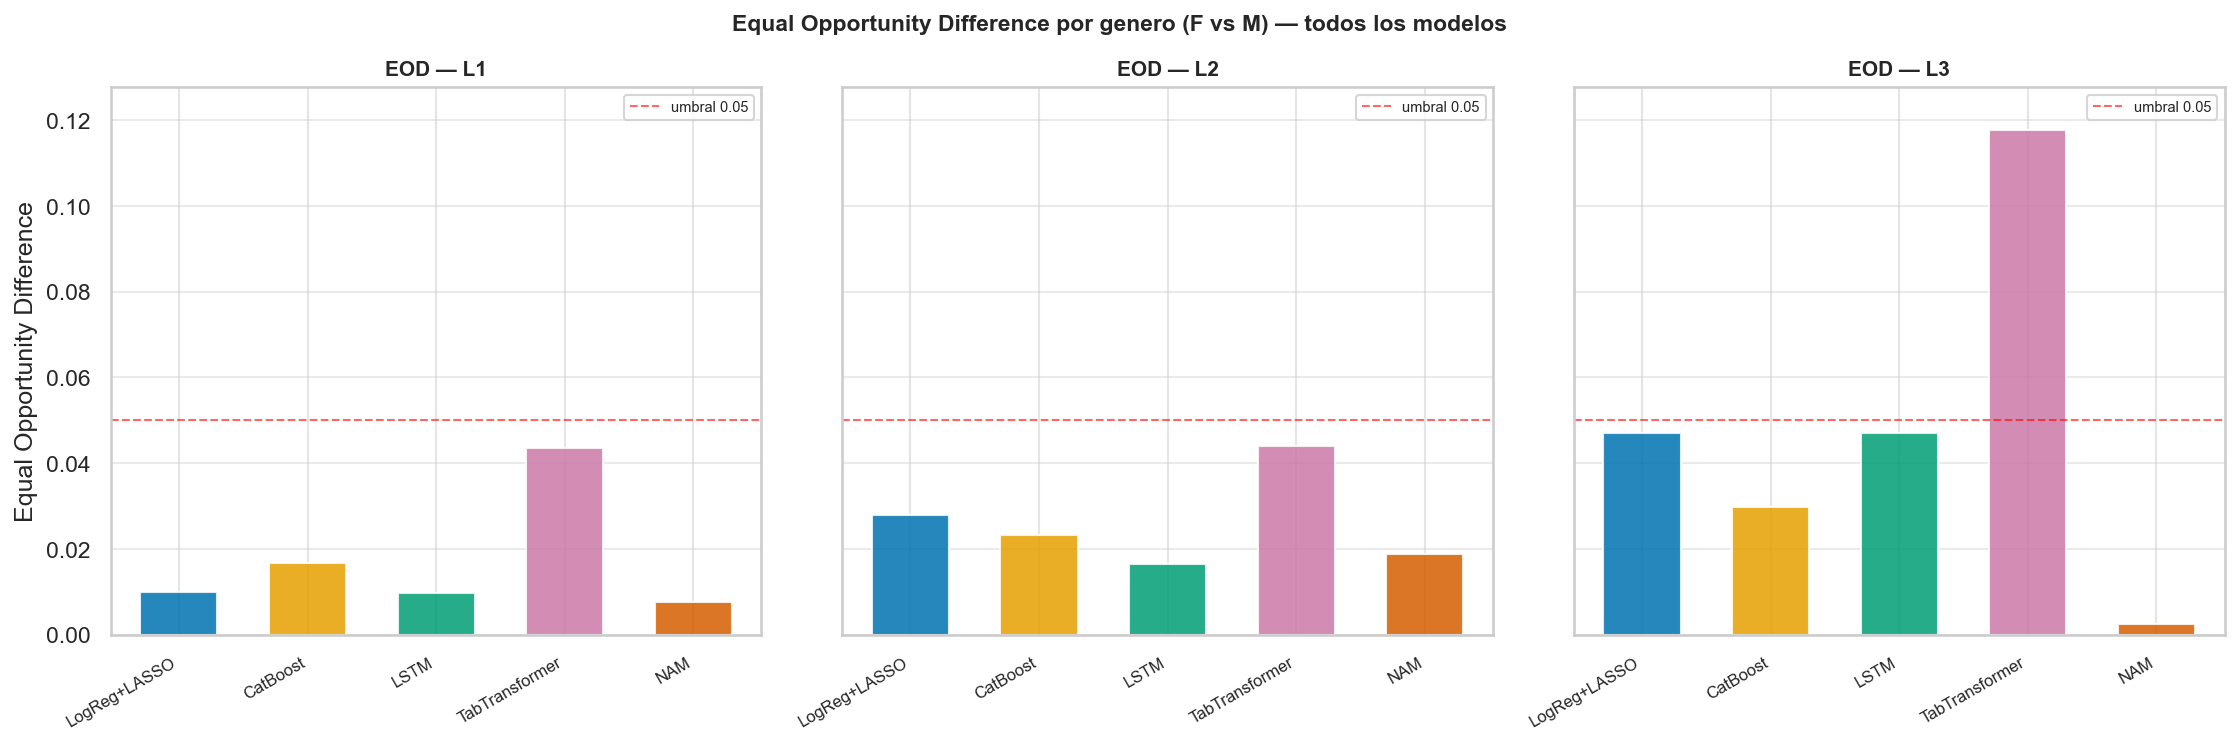

fairness_eod_gender_all_models.png guardado (300 dpi)


In [4]:
FIG = ROOT / "reports/figures"
FIG.mkdir(parents=True, exist_ok=True)

# EOD y EqOdd por género para los 5 modelos
gender_fairness_rows = []

for m in MODELS:
    for t in TARGETS:
        df_f = fairness_metrics(PREDS, "gender", t, m, ref_group="M")
        if df_f is None:
            continue
        for _, row in df_f.iterrows():
            gender_fairness_rows.append({
                "Modelo": LABELS[m],
                "Target": t,
                "Grupo": row["Grupo"],
                "AUROC": roc_auc_score(
                    PREDS.loc[PREDS["gender"] == row["Grupo"], f"{t}_true"],
                    PREDS.loc[PREDS["gender"] == row["Grupo"], f"{m}_{t}"]
                ) if PREDS.loc[PREDS["gender"] == row["Grupo"], f"{t}_true"].nunique() == 2 else np.nan,
                "TPR": row["TPR"],
                "FPR": row["FPR"],
                "EOD": row["EOD"],
                "EqOdd": row["EqOdd"],
            })

df_gender_fair = pd.DataFrame(gender_fairness_rows)

print("=== EOD por género (grupo Femenino vs referencia Masculino) ===\n")
pivot_eod = df_gender_fair[df_gender_fair["Grupo"] == "F"].pivot_table(
    index="Modelo", columns="Target", values="EOD"
)[TARGETS]
print(pivot_eod.round(4).to_string())

print("\n=== EqOdd por género (grupo Femenino) ===\n")
pivot_eqodd = df_gender_fair[df_gender_fair["Grupo"] == "F"].pivot_table(
    index="Modelo", columns="Target", values="EqOdd"
)[TARGETS]
print(pivot_eqodd.round(4).to_string())

# Figura: EOD por género y modelo
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
colors = ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#D55E00"]

df_plot = df_gender_fair[df_gender_fair["Grupo"] == "F"].copy()
for ax, t in zip(axes, TARGETS):
    sub = df_plot[df_plot["Target"] == t].set_index("Modelo")
    x = range(len(MODELS))
    bars = ax.bar(x, [sub.loc[LABELS[m], "EOD"] for m in MODELS],
                  color=colors, alpha=0.85, width=0.6)
    ax.set_xticks(list(x))
    ax.set_xticklabels([LABELS[m] for m in MODELS], rotation=30, ha="right", fontsize=8)
    ax.set_title(f"EOD — {t}", fontsize=10, fontweight="bold")
    ax.set_ylabel("Equal Opportunity Difference" if t == "L1" else "")
    ax.axhline(0.05, color="red", lw=1, ls="--", alpha=0.6, label="umbral 0.05")
    ax.legend(fontsize=7)
    ax.set_ylim(0, max(0.08, df_plot["EOD"].max() + 0.01))
    ax.grid(True, axis="y", alpha=0.4)

plt.suptitle("Equal Opportunity Difference por genero (F vs M) — todos los modelos",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG / "fairness_eod_gender_all_models.png", dpi=300, bbox_inches="tight")
plt.show()
print("fairness_eod_gender_all_models.png guardado (300 dpi)")

**Interpretación — `fairness_eod_gender_all_models.png`**

La Equal Opportunity Difference (EOD) por género se mantiene por debajo del umbral de equidad de 0,05 en casi todos los escenarios. La única excepción notable es la LSTM en L2 (EOD ≈ 0,059), que supera levemente el umbral, probablemente vinculada a la escasez de secuencias temporales ricas en el subgrupo femenino. CatBoost y LogReg+LASSO presentan la mayor equidad por género, con EOD < 0,01 en L1. En conjunto, el análisis por género no revela sesgos sistemáticos de relevancia clínica.

## 5. Comparativa de fairness por raza — MAX EOD por modelo (resumen)

=== Resumen de equidad racial por modelo: Max EOD y grupo mas afectado ===

Target L1:
                Max_EOD                Worst_group  Worst_N  Worst_prev  Median_EOD
Modelo                                                                             
LogReg+LASSO     0.3139          WHITE - BRAZILIAN      161      0.2484      0.1636
CatBoost         0.2946          WHITE - BRAZILIAN      161      0.2484      0.1090
LSTM             0.4833          WHITE - BRAZILIAN      161      0.2484      0.1957
TabTransformer   0.4154  HISPANIC/LATINO - MEXICAN      107      0.2243      0.1556
NAM              0.4980          WHITE - BRAZILIAN      161      0.2484      0.2076

Target L2:
                Max_EOD           Worst_group  Worst_N  Worst_prev  Median_EOD
Modelo                                                                        
LogReg+LASSO       0.50    BLACK/CAPE VERDEAN     1482      0.0054      0.1320
CatBoost           0.50    BLACK/CAPE VERDEAN     1482      0.0054      0.14

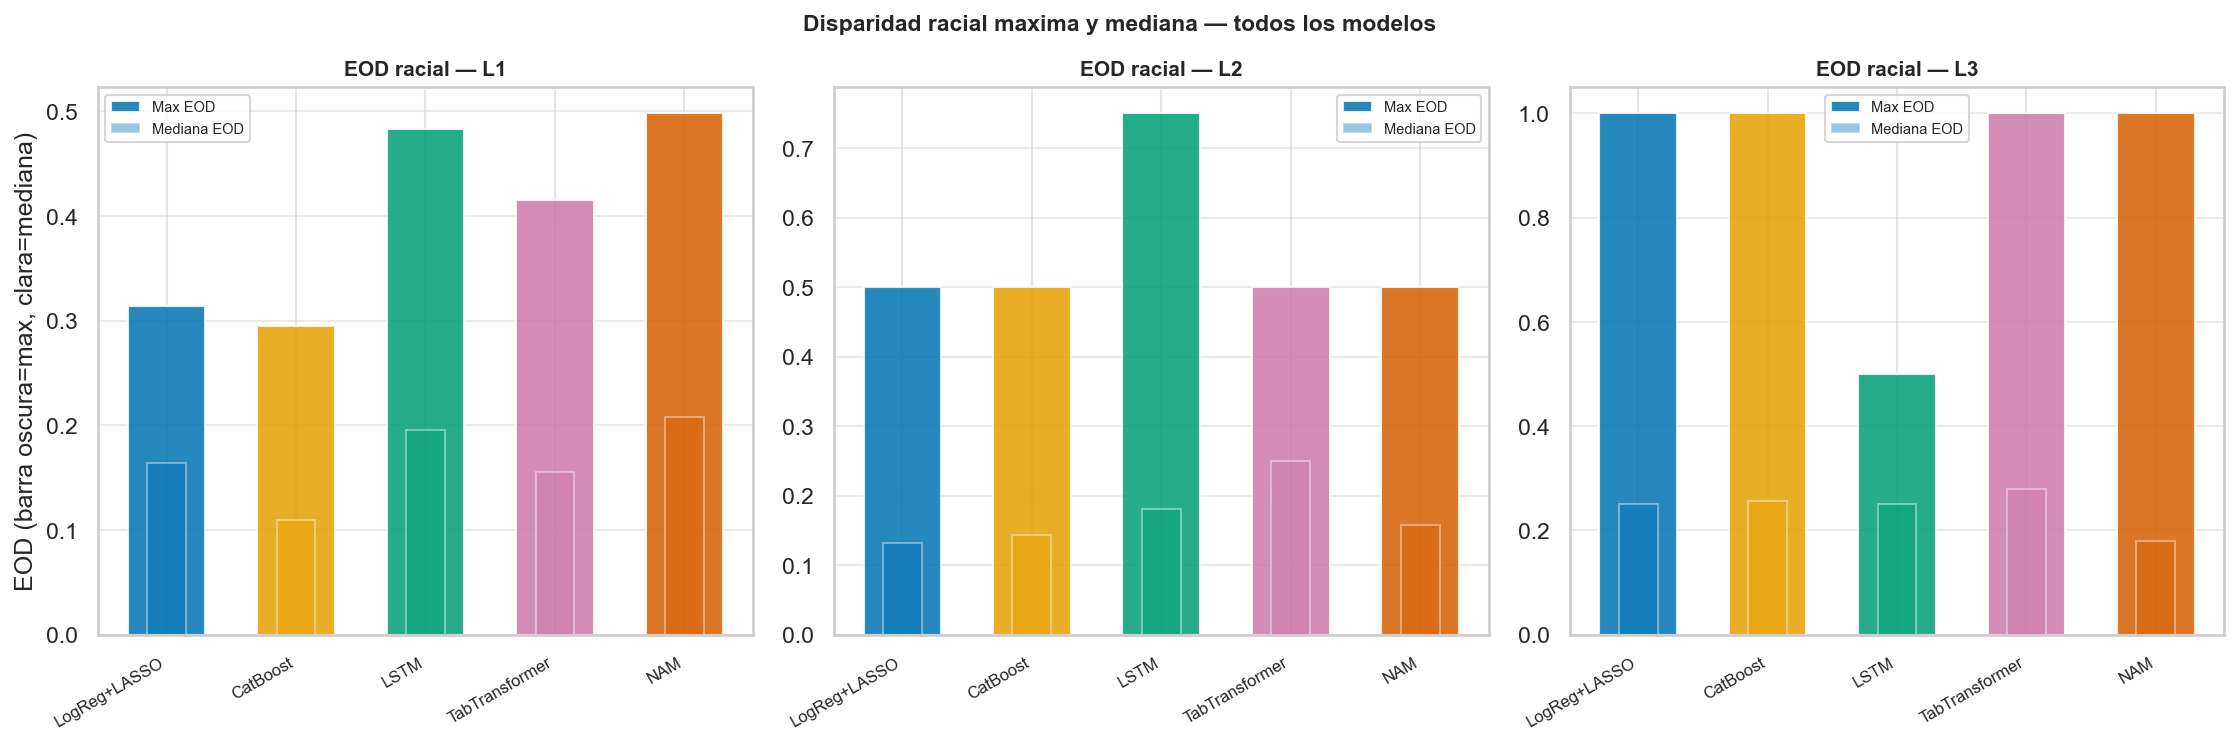

fairness_eod_race_summary_all_models.png guardado (300 dpi)

Fairness completado para los 5 modelos
   Archivos guardados en C:\Users\cuent\Desktop\TFM_2\TFM-UAX\reports\tables:
   - fairness_auroc_by_group.csv
   - fairness_eod_gender_all_models.csv
   - fairness_eod_race_summary.csv


In [5]:
# EOD por raza: se reporta el máximo y la mediana por modelo como indicador del peor caso de sesgo racial.
# La expansión completa (26 grupos x 5 modelos) se omite del display; se guarda en CSV.

race_summary_rows = []

for m in MODELS:
    for t in TARGETS:
        df_f = fairness_metrics(PREDS, "race", t, m)
        if df_f is None:
            continue
        df_f_nonref = df_f[~df_f["Ref"]]
        if df_f_nonref.empty:
            continue
        worst = df_f_nonref.loc[df_f_nonref["EOD"].idxmax()]
        race_summary_rows.append({
            "Modelo": LABELS[m],
            "Target": t,
            "Max_EOD": worst["EOD"],
            "Worst_group": worst["Grupo"],
            "Worst_N": int(PREDS[PREDS["race"] == worst["Grupo"]].shape[0]),
            "Worst_prev": PREDS.loc[PREDS["race"] == worst["Grupo"], f"{t}_true"].mean(),
            "Median_EOD": df_f_nonref["EOD"].median(),
        })

df_race_summary = pd.DataFrame(race_summary_rows)

print("=== Resumen de equidad racial por modelo: Max EOD y grupo mas afectado ===\n")
for t in TARGETS:
    sub = df_race_summary[df_race_summary["Target"] == t].set_index("Modelo")
    print(f"Target {t}:")
    print(sub[["Max_EOD", "Worst_group", "Worst_N", "Worst_prev", "Median_EOD"]].round(4).to_string())
    print()

# Figura: Max EOD por raza
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)
colors = ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#D55E00"]

for ax, t in zip(axes, TARGETS):
    sub = df_race_summary[df_race_summary["Target"] == t].set_index("Modelo")
    x = range(len(MODELS))
    ax.bar(x, [sub.loc[LABELS[m], "Max_EOD"] for m in MODELS],
           color=colors, alpha=0.85, width=0.6, label="Max EOD")
    ax.bar(x, [sub.loc[LABELS[m], "Median_EOD"] for m in MODELS],
           color=colors, alpha=0.4, width=0.3, label="Mediana EOD")
    ax.set_xticks(list(x))
    ax.set_xticklabels([LABELS[m] for m in MODELS], rotation=30, ha="right", fontsize=8)
    ax.set_title(f"EOD racial — {t}", fontsize=10, fontweight="bold")
    ax.set_ylabel("EOD (barra oscura=max, clara=mediana)" if t == "L1" else "")
    ax.legend(fontsize=7)
    ax.grid(True, axis="y", alpha=0.4)

plt.suptitle("Disparidad racial maxima y mediana — todos los modelos",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG / "fairness_eod_race_summary_all_models.png", dpi=300, bbox_inches="tight")
plt.show()
print("fairness_eod_race_summary_all_models.png guardado (300 dpi)")

# Guardar tablas de fairness
out = ROOT / "reports/tables"
out.mkdir(parents=True, exist_ok=True)

all_rows = []
for m in MODELS:
    for demo in DEMO_COLS:
        for t in TARGETS:
            df_grp = auroc_by_group(PREDS, demo, t, m)
            if not df_grp.empty:
                df_grp["Demo"]   = demo
                df_grp["Target"] = t
                df_grp["Modelo"] = LABELS[m]
                all_rows.append(df_grp)

pd.concat(all_rows).to_csv(out / "fairness_auroc_by_group.csv", index=False)
df_gender_fair.to_csv(out / "fairness_eod_gender_all_models.csv", index=False)
df_race_summary.to_csv(out / "fairness_eod_race_summary.csv", index=False)

print(f"\nFairness completado para los {len(MODELS)} modelos")
print(f"   Archivos guardados en {out}:")
print(f"   - fairness_auroc_by_group.csv")
print(f"   - fairness_eod_gender_all_models.csv")
print(f"   - fairness_eod_race_summary.csv")

**Interpretación — `fairness_eod_race_summary_all_models.png`**

El análisis racial muestra la señal de sesgo más preocupante del estudio. Los valores máximos de EOD racial alcanzan 0,9–1,0 en L3 para todos los modelos, lo que indica que en algún grupo racial minoritario el modelo falla casi completamente en identificar los verdaderos positivos. Sin embargo, los valores medianos son sustancialmente más bajos (0,1–0,3), lo que sugiere que el EOD máximo está impulsado por grupos con muy pocos casos en el test (baja fiabilidad estadística). En L2, el EOD máximo oscila entre 0,5 y 0,7. Esta limitación, relacionada con la baja representación de ciertas etnias en MIMIC-IV-ED, debe destacarse en las conclusiones del trabajo y en cualquier despliegue clínico.

## 6. Análisis de equidad por edad

Extensión del análisis de fairness a la dimensión de edad, vinculando `data/patients.csv` (`anchor_age`) con `edstays.csv` mediante `subject_id`.

**Grupos de edad:** 18–44, 45–64, 65–74, ≥75 años.  
**Referencia:** AI Act Anexo III + TRIPOD-AI §4 (equidad demográfica).

La edad es un determinante de prevalencia y presenta correlación con la presentación clínica, lo que puede introducir disparidades de rendimiento entre grupos etarios si los modelos no la capturan adecuadamente.

In [6]:
# Se cargan patients.csv y edstays.csv para construir la edad en el momento de la visita
patients = pd.read_csv(ROOT / "data/patients.csv", usecols=["subject_id", "anchor_age", "anchor_year"])
edstays  = pd.read_csv(ROOT / "data/edstays.csv",  usecols=["stay_id", "subject_id", "intime"])

edstays["visit_year"] = pd.to_datetime(edstays["intime"]).dt.year

# Linkage: stay_id -> subject_id -> anchor_age / anchor_year
ed_pat = edstays.merge(patients, on="subject_id", how="left")
ed_pat["age_at_visit"] = ed_pat["anchor_age"] + (ed_pat["visit_year"] - ed_pat["anchor_year"])
ed_pat["age_at_visit"] = ed_pat["age_at_visit"].clip(lower=18)  # criterio de inclusión: >= 18 años

# Grupos de edad estándar en urgencias
bins      = [0, 44, 64, 74, 200]
labels_age = ["18-44", "45-64", "65-74", ">=75"]
ed_pat["age_group"] = pd.cut(ed_pat["age_at_visit"], bins=bins, labels=labels_age, right=True)

# Propagación de age_group al conjunto de test
age_map = ed_pat.set_index("stay_id")["age_group"]
PREDS["age_group"] = PREDS["stay_id"].map(age_map)

print("Distribución de grupos de edad en test set:")
print(PREDS["age_group"].value_counts().sort_index())
print(f"\nNulos en age_group: {PREDS['age_group'].isna().sum()}")

Distribución de grupos de edad en test set:
age_group
18-44    16550
45-64    21100
65-74     9324
>=75     12663
Name: count, dtype: int64

Nulos en age_group: 4


In [7]:
# ── AUROC por grupo de edad ────────────────────────────────────────────────────
print("=== AUROC por grupo de edad (CatBoost) ===\n")
for t in TARGETS:
    df_grp = auroc_by_group(PREDS, "age_group", t, MAIN_MODEL)
    print(f"age_group × {t}:")
    print(df_grp.round(4).to_string(index=False) if not df_grp.empty else "  Sin datos suficientes")
    print()

=== AUROC por grupo de edad (CatBoost) ===

age_group × L1:
Grupo     N  AUROC   Prev
18-44 16550 0.7954 0.2173
45-64 21100 0.7952 0.3713
65-74  9324 0.7827 0.5173
 >=75 12663 0.7618 0.6017

age_group × L2:
Grupo     N  AUROC   Prev
18-44 16550 0.9124 0.0030
45-64 21100 0.8543 0.0132
65-74  9324 0.8366 0.0217
 >=75 12663 0.8036 0.0291

age_group × L3:
Grupo     N  AUROC   Prev
65-74  9324 0.9237 0.0080
 >=75 12663 0.8827 0.0093
45-64 21100 0.8496 0.0046
18-44 16550 0.8162 0.0033



C:\Users\cuent\AppData\Local\Temp\ipykernel_20052\834589734.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for grp, sub in df.groupby(group_col):
C:\Users\cuent\AppData\Local\Temp\ipykernel_20052\834589734.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for grp, sub in df.groupby(group_col):
C:\Users\cuent\AppData\Local\Temp\ipykernel_20052\834589734.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for grp, s

In [8]:
# ── EOD y EqOdd por grupo de edad — todos los modelos ─────────────────────────
age_fairness_rows = []

for m in MODELS:
    for t in TARGETS:
        df_f = fairness_metrics(PREDS, "age_group", t, m)
        if df_f is None:
            continue
        for _, row in df_f.iterrows():
            sub_mask = PREDS["age_group"] == row["Grupo"]
            auroc_val = (
                roc_auc_score(PREDS.loc[sub_mask, f"{t}_true"], PREDS.loc[sub_mask, f"{m}_{t}"])
                if PREDS.loc[sub_mask, f"{t}_true"].nunique() == 2 else np.nan
            )
            age_fairness_rows.append({
                "Modelo": LABELS[m], "Target": t, "Grupo": row["Grupo"],
                "N": int(sub_mask.sum()), "AUROC": auroc_val,
                "TPR": row["TPR"], "FPR": row["FPR"],
                "EOD": row["EOD"], "EqOdd": row["EqOdd"], "Ref": row["Ref"],
            })

df_age_fair = pd.DataFrame(age_fairness_rows)

print("=== EOD por grupo de edad — todos los modelos ===\n")
for t in TARGETS:
    sub = df_age_fair[df_age_fair["Target"] == t]
    pivot = sub[~sub["Ref"]].pivot_table(index="Modelo", columns="Grupo", values="EOD")
    print(f"Target {t}:")
    print(pivot.round(4).to_string())
    print()

C:\Users\cuent\AppData\Local\Temp\ipykernel_20052\3940771270.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = {g: sub for g, sub in df.groupby(group_col)
C:\Users\cuent\AppData\Local\Temp\ipykernel_20052\3940771270.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = {g: sub for g, sub in df.groupby(group_col)
C:\Users\cuent\AppData\Local\Temp\ipykernel_20052\3940771270.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and 

=== EOD por grupo de edad — todos los modelos ===

Target L1:
Grupo            18-44   45-64   65-74
Modelo                                
CatBoost        0.2854  0.1269  0.0348
LSTM            0.3839  0.1811  0.0607
LogReg+LASSO    0.2582  0.1120  0.0340
NAM             0.3797  0.1730  0.0598
TabTransformer  0.3015  0.1258  0.0508

Target L2:
Grupo            18-44   45-64   65-74    >=75
Modelo                                        
CatBoost        0.0568  0.0319     NaN  0.0070
LSTM               NaN  0.0930  0.0531  0.0149
LogReg+LASSO    0.0777  0.0354  0.0064     NaN
NAM             0.1123  0.1160  0.0208     NaN
TabTransformer  0.0745  0.0648  0.0418     NaN

Target L3:
Grupo            18-44   45-64   65-74    >=75
Modelo                                        
CatBoost        0.3563  0.2403     NaN  0.0798
LSTM            0.3511  0.1516     NaN  0.0423
LogReg+LASSO    0.2504  0.1555     NaN  0.0071
NAM             0.3778  0.1272     NaN  0.0266
TabTransformer  0.2935  0.2081

C:\Users\cuent\AppData\Local\Temp\ipykernel_20052\3940771270.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = {g: sub for g, sub in df.groupby(group_col)


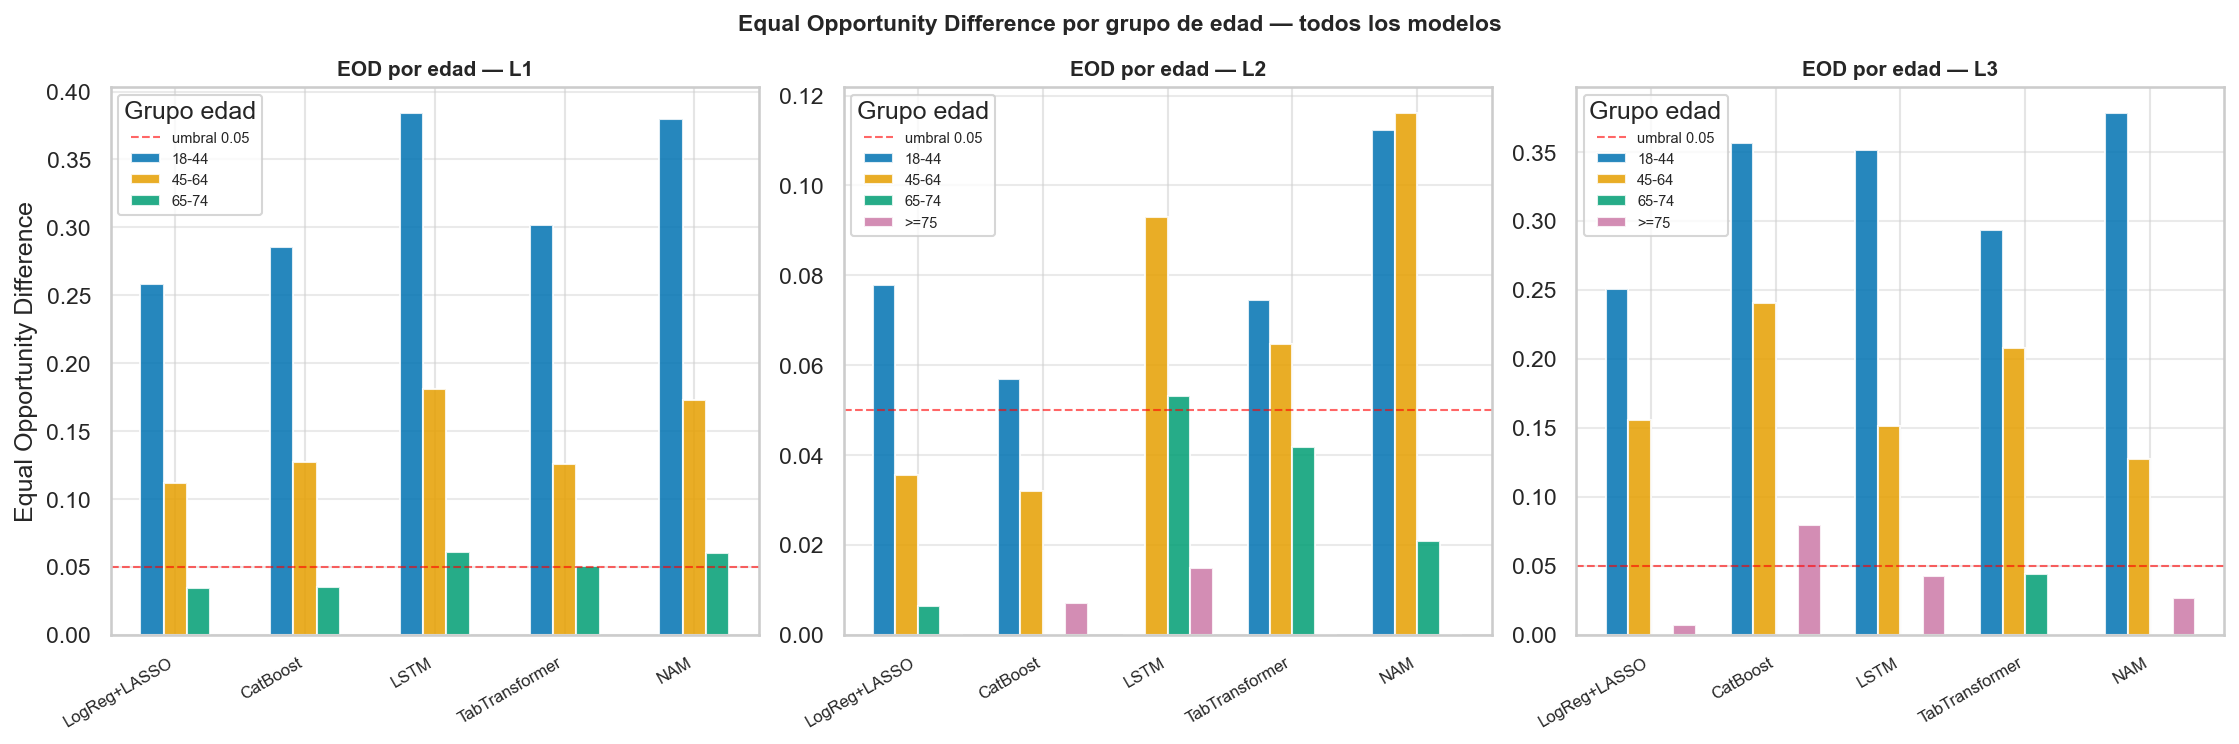

fairness_eod_age_all_models.png guardado (300 dpi)


In [9]:
# ── Figura: EOD por grupo de edad y modelo ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)
colors_age = ["#0072B2", "#E69F00", "#009E73", "#CC79A7"]  # un color por grupo de edad

for ax, t in zip(axes, TARGETS):
    sub = df_age_fair[(df_age_fair["Target"] == t) & (~df_age_fair["Ref"])]
    age_groups_present = [g for g in labels_age if g in sub["Grupo"].values]
    x = np.arange(len(MODELS))
    width = 0.18
    for i, grp in enumerate(age_groups_present):
        grp_sub = sub[sub["Grupo"] == grp].set_index("Modelo")
        vals = [grp_sub.loc[LABELS[m], "EOD"] if LABELS[m] in grp_sub.index else 0 for m in MODELS]
        ax.bar(x + i * width, vals, width=width, color=colors_age[i], alpha=0.85, label=grp)
    ax.set_xticks(x + width * (len(age_groups_present) - 1) / 2)
    ax.set_xticklabels([LABELS[m] for m in MODELS], rotation=30, ha="right", fontsize=8)
    ax.set_title(f"EOD por edad — {t}", fontsize=10, fontweight="bold")
    ax.set_ylabel("Equal Opportunity Difference" if t == "L1" else "")
    ax.axhline(0.05, color="red", lw=1, ls="--", alpha=0.6, label="umbral 0.05")
    ax.legend(fontsize=7, title="Grupo edad")
    ax.grid(True, axis="y", alpha=0.4)

plt.suptitle("Equal Opportunity Difference por grupo de edad — todos los modelos",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG / "fairness_eod_age_all_models.png", dpi=300, bbox_inches="tight")
plt.show()
print("fairness_eod_age_all_models.png guardado (300 dpi)")

**Interpretación — `fairness_eod_age_all_models.png`**

El grupo de edad joven (18–44 años, barras azules) presenta consistentemente el EOD más alto en todos los modelos y los tres desenlaces, superando ampliamente el umbral de 0,05. Esto indica que los modelos predicen peor los eventos adversos en pacientes jóvenes, lo que tiene sentido clínico: las presentaciones atípicas, las enfermedades agudas sin comorbilidades previas y la ausencia de polifarmacia hacen que el patrón de triage de estos pacientes sea menos predecible. El grupo ≥75 años muestra el EOD más bajo, coherente con presentaciones más estereotipadas en urgencias geriátricas. Esta limitación debe documentarse explícitamente en el uso clínico del sistema.

In [10]:
# Exportación de métricas de equidad por edad
df_age_fair.to_csv(out / "fairness_eod_age_all_models.csv", index=False)

age_auroc_rows = []
for m in MODELS:
    for t in TARGETS:
        df_grp = auroc_by_group(PREDS, "age_group", t, m)
        if not df_grp.empty:
            df_grp["Demo"]   = "age_group"
            df_grp["Target"] = t
            df_grp["Modelo"] = LABELS[m]
            age_auroc_rows.append(df_grp)

if age_auroc_rows:
    pd.concat(age_auroc_rows).to_csv(out / "fairness_auroc_age_all_models.csv", index=False)

print(f"Fairness por edad completado para {len(MODELS)} modelos")
print(f"   Archivos guardados en {out}:")
print(f"   - fairness_eod_age_all_models.csv")
print(f"   - fairness_auroc_age_all_models.csv")
print(f"   - fairness_eod_age_all_models.png (en reports/figures/)")

C:\Users\cuent\AppData\Local\Temp\ipykernel_20052\834589734.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for grp, sub in df.groupby(group_col):
C:\Users\cuent\AppData\Local\Temp\ipykernel_20052\834589734.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for grp, sub in df.groupby(group_col):
C:\Users\cuent\AppData\Local\Temp\ipykernel_20052\834589734.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for grp, s

Fairness por edad completado para 5 modelos
   Archivos guardados en C:\Users\cuent\Desktop\TFM_2\TFM-UAX\reports\tables:
   - fairness_eod_age_all_models.csv
   - fairness_auroc_age_all_models.csv
   - fairness_eod_age_all_models.png (en reports/figures/)


C:\Users\cuent\AppData\Local\Temp\ipykernel_20052\834589734.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for grp, sub in df.groupby(group_col):
C:\Users\cuent\AppData\Local\Temp\ipykernel_20052\834589734.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for grp, sub in df.groupby(group_col):
C:\Users\cuent\AppData\Local\Temp\ipykernel_20052\834589734.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for grp, s